# Claim Severity Across the freMTPL2 Portfolio

This notebook describes the amount of a claim **conditional on a claim being recorded**. It uses the `freMTPL2sev` claim records and links policy characteristics from `freMTPL2freq`, both exported from the CASdatasets R package. The [data intake and integrity notebook](01_data_overview.ipynb) documents the source checks; the [frequency notebook](02_frequency_exploration.ipynb) analyzes claim counts per exposure-year.

The unit of observation here is a **claim**, not a policy. A policy with multiple claims contributes multiple rows. Mean claim amount is the actuarial severity measure used later with claim frequency; medians and upper quantiles show how sensitive that mean may be to the right tail. All comparisons below are marginal descriptions, with no adjustment for other characteristics and no severity model. This full-portfolio descriptive analysis predates the development/test split introduced in Notebook 04.

## 1. Load claims and attach policy characteristics

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

frequency = pd.read_csv(
    Path("../data/raw/freMTPL2freq.csv"), dtype={"IDpol": "string"}
)
severity = pd.read_csv(
    Path("../data/raw/freMTPL2sev.csv"), dtype={"IDpol": "string"}
)

claims = severity.merge(
    frequency,
    on="IDpol",
    how="left",
    validate="many_to_one",
    indicator=True,
)
print("Claim-to-policy linkage:")
display(claims["_merge"].value_counts().rename("claim_rows").to_frame())
claims = claims.drop(columns="_merge")
print("Claims available for severity EDA:", len(claims))
display(claims[["IDpol", "ClaimAmount", "DrivAge", "VehAge", "Area"]].head(3))

Claim-to-policy linkage:


,claim_rows
_merge,
both,26444
left_only,0
right_only,0


Claims available for severity EDA: 26444


,IDpol,ClaimAmount,DrivAge,VehAge,Area
0,1552,995.20,39,0,D
1,1010996,1128.12,49,1,E
2,4024277,1851.11,32,2,D


## 2. Distribution and concentration

Claim amounts have a long right tail. The histogram uses logarithmic axes to show both the mass of ordinary claims and the rare large amounts. Repeated exact amounts may reflect fixed settlements or reporting conventions; the [CASdatasets notes](https://dutangc.github.io/CASdatasets/reference/freMTPL.html) mention fixed amounts under the French IRSA-IDA convention. The data are kept as supplied.

In [2]:
amounts = claims["ClaimAmount"]
portfolio_mean_severity = amounts.mean()

display(pd.DataFrame({
    "claim_count": [len(amounts)],
    "total_claim_amount": [amounts.sum()],
    "mean_claim_amount": [portfolio_mean_severity],
    "median_claim_amount": [amounts.median()],
}).round(2))

display(amounts.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0])
        .rename("claim_amount").to_frame().round(2))

,claim_count,total_claim_amount,mean_claim_amount,median_claim_amount
0,26444,59909216.5,2265.51,1172.0


,claim_amount
0.000,1.00
0.250,685.99
0.500,1172.00
0.750,1212.38
0.900,2767.60
0.950,4765.09
0.990,16451.22
0.999,152223.24
1.000,4075400.56


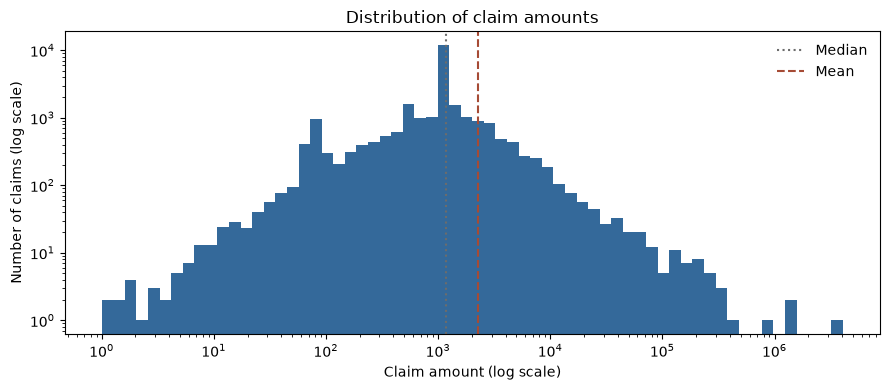

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(np.log10(amounts.min()), np.log10(amounts.max()), 65)
ax.hist(amounts, bins=bins, color="#34699a")
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(amounts.median(), color="#6c6c6c", linestyle=":",
           label="Median")
ax.axvline(portfolio_mean_severity, color="#a64b35", linestyle="--",
           label="Mean")
ax.set(title="Distribution of claim amounts",
       xlabel="Claim amount (log scale)", ylabel="Number of claims (log scale)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [4]:
concentration = []
for share_of_claims in [0.001, 0.01, 0.05]:
    n_largest = int(np.ceil(len(amounts) * share_of_claims))
    concentration.append({
        "largest_claim_share": f"{share_of_claims:.1%}",
        "claim_count": n_largest,
        "share_of_total_amount": amounts.nlargest(n_largest).sum() / amounts.sum(),
    })
display(pd.DataFrame(concentration).set_index("largest_claim_share").round(3))

print("Most common exact claim amounts:")
display(amounts.value_counts().head(10).rename("claim_count").to_frame())

print("Largest individual claims:")
display(claims.nlargest(10, "ClaimAmount")[["IDpol", "ClaimAmount"]])

,claim_count,share_of_total_amount
largest_claim_share,,
0.1%,27,0.216
1.0%,265,0.380
5.0%,1323,0.521


Most common exact claim amounts:


,claim_count
ClaimAmount,
1204.00,4792
1128.12,3056
1172.00,2071
1128.00,831
602.00,433
1320.00,175
556.14,155
586.00,103
564.06,94


Largest individual claims:


,IDpol,ClaimAmount
9756,1120377,4075400.56
15768,110846,1403057.40
11637,2141337,1301172.60
17992,3122016,774411.50
2869,2008127,390742.27
3307,3025890,369131.88
9999,1117644,307096.42
5521,158309,301635.49
18627,3075820,287423.00
18295,3150210,281897.49


### Cumulative concentration of claim costs

The Lorenz curve orders claims from smallest to largest and compares their cumulative share of **claim count** with their cumulative share of **total claim amount**. The dashed diagonal shows equal claim amounts. This complements the top-claim shares above without changing or omitting any claims.

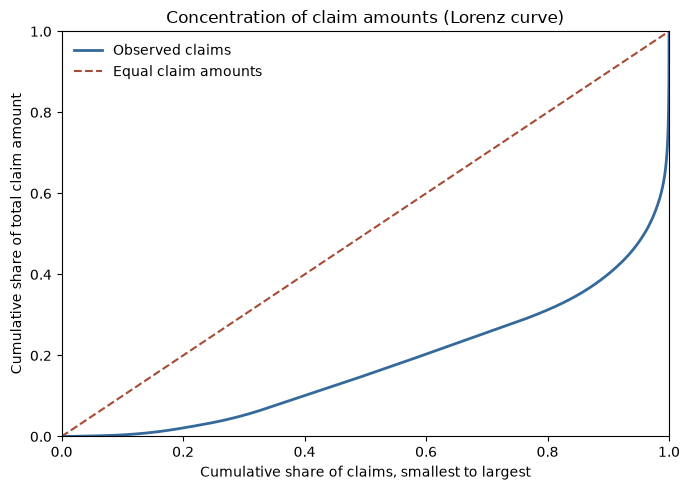

In [5]:
sorted_amounts = np.sort(amounts.to_numpy())
cumulative_claim_share = np.r_[0, np.arange(1, len(sorted_amounts) + 1)
                               / len(sorted_amounts)]
cumulative_amount_share = np.r_[0, np.cumsum(sorted_amounts)
                                / sorted_amounts.sum()]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cumulative_claim_share, cumulative_amount_share,
        color="#34699a", linewidth=2, label="Observed claims")
ax.plot([0, 1], [0, 1], color="#a64b35", linestyle="--",
        label="Equal claim amounts")
ax.set(title="Concentration of claim amounts (Lorenz curve)",
       xlabel="Cumulative share of claims, smallest to largest",
       ylabel="Cumulative share of total claim amount",
       xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Compare severity across policy characteristics

Each group table reports claim count, mean, median, 90th percentile, and total claim amount. The bar charts show the **mean claim amount**, the quantity used in a frequency–severity decomposition. A group's mean can be moved sharply by a small number of large claims, especially where claim counts are limited.

In [6]:
def severity_by_group(data, group):
    summary = data.groupby(group, observed=True, dropna=False)["ClaimAmount"].agg(
        claim_count="size",
        mean_claim_amount="mean",
        median_claim_amount="median",
        p90_claim_amount=lambda values: values.quantile(0.9),
        total_claim_amount="sum",
    )
    summary["relative_mean_to_portfolio"] = (
        summary["mean_claim_amount"] / portfolio_mean_severity
    )
    return summary


def plot_mean_severity(summary, title, *, rotation=0):
    ax = summary["mean_claim_amount"].plot.bar(
        figsize=(9, 4), color="#34699a", rot=rotation, legend=False
    )
    reference_line = ax.axhline(
        portfolio_mean_severity, color="#a64b35", linestyle="--",
        label="Portfolio mean",
    )
    ax.set(title=title, xlabel="", ylabel="Mean claim amount")
    ax.legend(handles=[reference_line], frameon=False)
    plt.tight_layout()
    plt.show()

### Driver characteristics

,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
driver_age_band,,,,,,
18–24,2011,5838.56,1172.00,3251.61,11741344.21,2.58
25–34,4973,2002.30,1128.12,2906.83,9957419.91,0.88
35–44,6192,1983.93,1167.46,2715.55,12284481.34,0.88
45–54,6802,1847.96,1172.00,2794.38,12569823.09,0.82
55–64,3602,1859.34,1172.00,2583.01,6697343.57,0.82
65–74,1872,2202.87,1172.00,2551.58,4123771.44,0.97
75+,992,2555.48,1204.00,2670.66,2535032.94,1.13


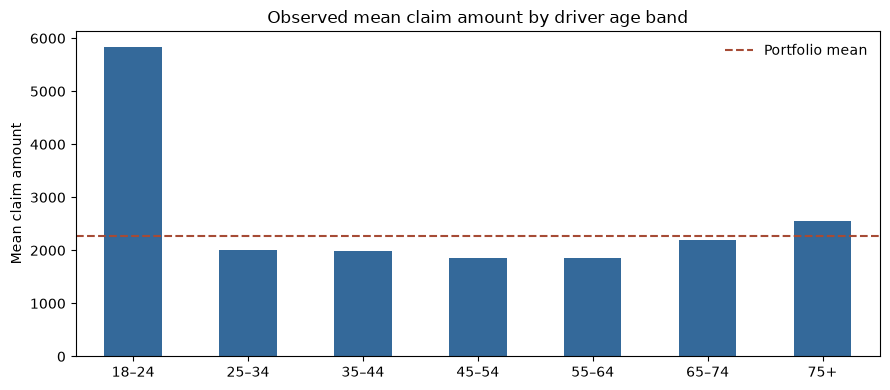

In [7]:
claims["driver_age_band"] = pd.cut(
    claims["DrivAge"],
    bins=[18, 25, 35, 45, 55, 65, 75, float("inf")],
    labels=["18–24", "25–34", "35–44", "45–54", "55–64", "65–74", "75+"],
    right=False,
)
driver_age_summary = severity_by_group(claims, "driver_age_band")
display(driver_age_summary.round(2))
plot_mean_severity(driver_age_summary,
                   "Observed mean claim amount by driver age band")

,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
bonus_malus_band,,,,,,
<75,19283,1951.69,1172.0,2680.80,37634355.17,0.86
75–99,4585,2078.06,1172.0,3077.25,9527883.19,0.92
100–124,2124,5536.74,1172.0,2934.01,11760041.99,2.44
125+,452,2183.49,1172.0,2406.42,986936.15,0.96


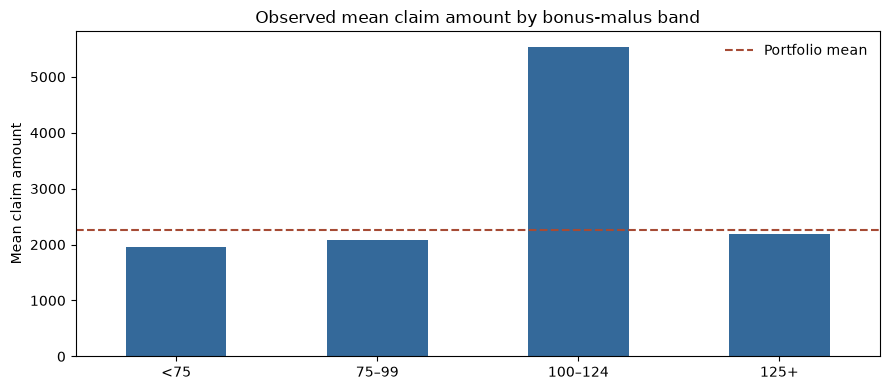

In [8]:
claims["bonus_malus_band"] = pd.cut(
    claims["BonusMalus"],
    bins=[0, 75, 100, 125, float("inf")],
    labels=["<75", "75–99", "100–124", "125+"],
    right=False,
)
bonus_malus_summary = severity_by_group(claims, "bonus_malus_band")
display(bonus_malus_summary.round(2))
plot_mean_severity(bonus_malus_summary,
                   "Observed mean claim amount by bonus-malus band")

### Vehicle characteristics

,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
vehicle_age_band,,,,,,
0,1181,1985.54,1172.00,3000.00,2344917.42,0.88
1–2,4566,2180.19,1172.00,2997.47,9954744.92,0.96
3–5,5344,1974.72,1172.00,3000.00,10552899.23,0.87
6–10,8009,1973.41,1159.53,2875.64,15805071.87,0.87
11–20,7137,2917.02,1144.64,2360.58,20818738.75,1.29
21+,207,2091.04,1172.00,1745.77,432844.31,0.92


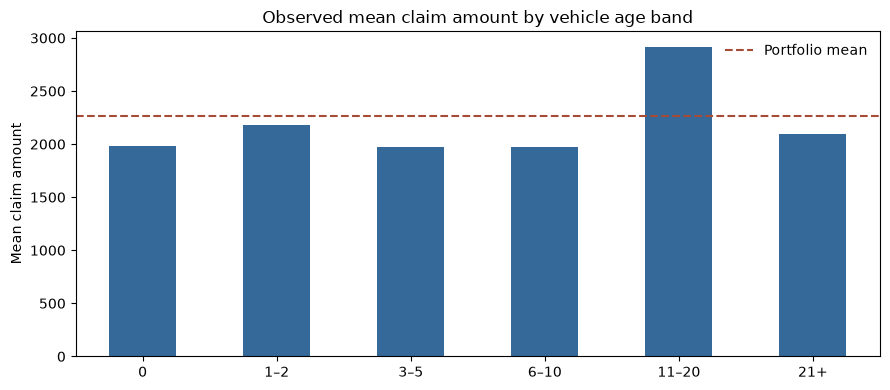

Fuel type


,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
VehGas,,,,,,
Diesel,13450,2051.65,1172.0,2812.1,27594673.95,0.91
Regular,12994,2486.88,1172.0,2704.0,32314542.55,1.10


In [9]:
claims["vehicle_age_band"] = pd.cut(
    claims["VehAge"],
    bins=[0, 1, 3, 6, 11, 21, float("inf")],
    labels=["0", "1–2", "3–5", "6–10", "11–20", "21+"],
    right=False,
)
vehicle_age_summary = severity_by_group(claims, "vehicle_age_band")
display(vehicle_age_summary.round(2))
plot_mean_severity(vehicle_age_summary,
                   "Observed mean claim amount by vehicle age band")

print("Fuel type")
display(severity_by_group(claims, "VehGas").round(2))

In [10]:
print("Vehicle power")
display(severity_by_group(claims, "VehPower").round(2))

print("Vehicle brand code")
brand_summary = severity_by_group(claims, "VehBrand")
brand_summary = brand_summary.reindex(
    sorted(brand_summary.index, key=lambda brand: int(brand[1:]))
)
display(brand_summary.round(2))

Vehicle power


,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
VehPower,,,,,,
4,4003,2350.76,1172.00,2524.00,9410083.43,1.04
5,5115,1727.81,1172.00,2720.47,8837747.14,0.76
6,6305,2281.67,1161.32,2869.54,14385946.83,1.01
7,5593,2221.78,1172.00,2756.35,12426397.16,0.98
8,1645,1796.15,1172.00,2699.73,2954665.51,0.79
9,1220,5135.29,1172.00,3000.00,6265052.65,2.27
10,1217,2344.55,1172.00,3036.44,2853312.33,1.03
11,714,1837.72,1204.00,2819.64,1312132.16,0.81
12,296,2390.82,1204.00,3625.66,707682.28,1.06


Vehicle brand code


,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
VehBrand,,,,,,
B1,6898,2096.60,1128.12,2734.18,14462378.14,0.93
B2,6805,2762.86,1172.00,2841.58,18801244.90,1.22
B3,2429,2139.97,1172.00,3000.00,5197982.07,0.94
B4,1099,2316.97,1128.12,2686.58,2546351.21,1.02
B5,1662,1745.52,1128.12,2409.68,2901047.93,0.77
B6,1252,1563.51,1128.12,2289.86,1957513.74,0.69
B10,765,2200.39,1165.43,3392.96,1683301.31,0.97
B11,664,3356.81,1128.12,3222.61,2228920.37,1.48
B12,4200,2082.64,1204.00,2574.48,8747094.58,0.92


### Geography

The density cut points are derived from quintiles of the **policy-level** frequency table, as in the frequency notebook. Applying those same cut points to claims makes the group definitions comparable across notebooks. Mean and median amounts remain claim-level statistics.

,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
Area,,,,,,
A,3364,2300.72,1172.0,2652.11,7739630.67,1.02
B,2633,3370.29,1172.0,2643.93,8873979.52,1.49
C,7093,2060.07,1172.0,2668.82,14612072.43,0.91
D,6458,2243.19,1172.0,2939.44,14486501.16,0.99
E,6122,2126.34,1172.0,3000.00,13017426.30,0.94
F,774,1524.04,1172.0,2115.51,1179606.42,0.67


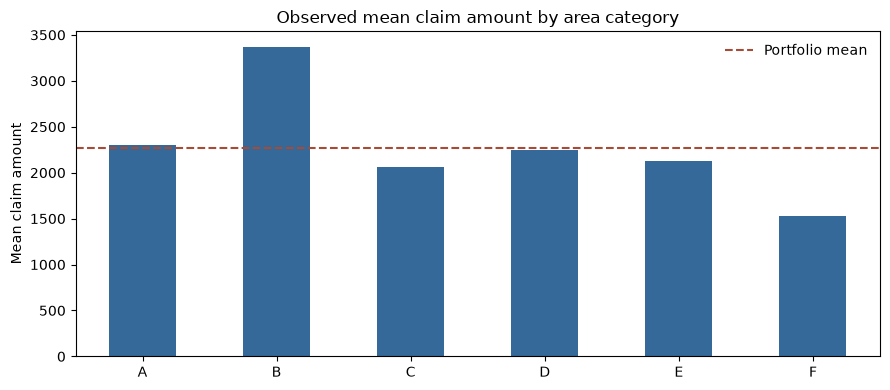

,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
Density (inhabitants/km²),,,,,,
1–67,4522,2229.52,1172.0,2650.84,10081880.20,0.98
68–214,4839,2883.71,1172.0,2672.00,13954250.52,1.27
215–716,5102,1951.48,1172.0,2669.12,9956455.91,0.86
"717–2,715",6077,2305.45,1172.0,2956.87,14010243.86,1.02
"2,716–27,000",5904,2016.66,1172.0,2961.90,11906386.01,0.89


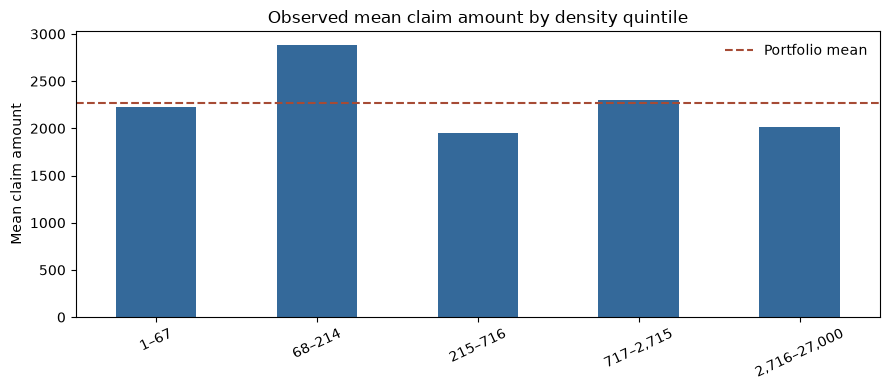

In [11]:
area_summary = severity_by_group(claims, "Area").sort_index()
display(area_summary.round(2))
plot_mean_severity(area_summary, "Observed mean claim amount by area category")

_, density_edges = pd.qcut(
    frequency["Density"], q=5, retbins=True, duplicates="drop"
)
claims["density_quintile"] = pd.cut(
    claims["Density"], bins=density_edges, include_lowest=True
)
density_summary = severity_by_group(claims, "density_quintile")
density_summary.index = pd.Index(
    [f"{int(interval.left) + 1:,}–{int(interval.right):,}"
     for interval in density_summary.index],
    name="Density (inhabitants/km²)",
)
display(density_summary.round(2))
plot_mean_severity(density_summary,
                   "Observed mean claim amount by density quintile",
                   rotation=25)

In [12]:
region_summary = severity_by_group(claims, "Region")
display(region_summary.sort_values("claim_count", ascending=False).round(2))

,claim_count,mean_claim_amount,median_claim_amount,p90_claim_amount,total_claim_amount,relative_mean_to_portfolio
Region,,,,,,
Centre,6475,2945.92,1128.12,2611.60,19074802.36,1.30
Rhone-Alpes,4233,2428.14,1172.00,2943.17,10278303.85,1.07
Provence-Alpes-Cotes-D'Azur,2986,2301.08,1172.00,3775.76,6871024.80,1.02
Ile-de-France,2591,1761.18,1172.00,2524.00,4563221.86,0.78
Bretagne,1871,2085.01,1147.46,2681.50,3901051.25,0.92
Pays-de-la-Loire,1576,1631.32,1128.12,2345.39,2570964.93,0.72
Languedoc-Roussillon,1068,1901.60,1186.94,3027.51,2030911.08,0.84
Aquitaine,1055,1816.25,1172.00,2964.29,1916138.54,0.80
Nord-Pas-de-Calais,944,1731.66,1172.00,2772.39,1634689.72,0.76


## 4. Sensitivity of mean severity to the upper tail

As a **diagnostic only**, cap each claim amount at the portfolio-wide 99th percentile and compare the resulting group means with the original means. The same cap is used for every group. This shows where a small number of extreme claims has a large effect on a marginal comparison. It does **not** redefine severity or propose excluding large claims from expected-cost estimates.

In [13]:
tail_cap = amounts.quantile(0.99)
claims["ClaimAmount_p99_capped"] = claims["ClaimAmount"].clip(upper=tail_cap)

print(f"Portfolio-wide 99th-percentile cap: {tail_cap:,.2f}")
print("Claims above cap:", (amounts > tail_cap).sum())
display(pd.DataFrame({
    "original_mean": [amounts.mean()],
    "p99_capped_mean": [claims["ClaimAmount_p99_capped"].mean()],
    "reduction_in_mean_pct": [
        100 * (1 - claims["ClaimAmount_p99_capped"].mean() / amounts.mean())
    ],
}).round(2))

Portfolio-wide 99th-percentile cap: 16,451.22
Claims above cap: 265


,original_mean,p99_capped_mean,reduction_in_mean_pct
0,2265.51,1569.16,30.74


In [14]:
def tail_sensitivity_by_group(data, group):
    summary = data.groupby(group, observed=True, dropna=False).agg(
        claim_count=("ClaimAmount", "size"),
        original_mean=("ClaimAmount", "mean"),
        p99_capped_mean=("ClaimAmount_p99_capped", "mean"),
    )
    summary["reduction_in_mean_pct"] = (
        100 * (1 - summary["p99_capped_mean"] / summary["original_mean"])
    )
    return summary.round(2)


for label, group in [
    ("Driver age", "driver_age_band"),
    ("BonusMalus", "bonus_malus_band"),
    ("Vehicle age", "vehicle_age_band"),
    ("Area", "Area"),
]:
    print(label)
    display(tail_sensitivity_by_group(claims, group))

Driver age


,claim_count,original_mean,p99_capped_mean,reduction_in_mean_pct
driver_age_band,,,,
18–24,2011,5838.56,1772.92,69.63
25–34,4973,2002.30,1555.47,22.32
35–44,6192,1983.93,1534.44,22.66
45–54,6802,1847.96,1568.76,15.11
55–64,3602,1859.34,1494.96,19.60
65–74,1872,2202.87,1572.17,28.63
75+,992,2555.48,1707.92,33.17


BonusMalus


,claim_count,original_mean,p99_capped_mean,reduction_in_mean_pct
bonus_malus_band,,,,
<75,19283,1951.69,1529.41,21.64
75–99,4585,2078.06,1645.94,20.79
100–124,2124,5536.74,1743.97,68.50
125+,452,2183.49,1664.58,23.77


Vehicle age


,claim_count,original_mean,p99_capped_mean,reduction_in_mean_pct
vehicle_age_band,,,,
0,1181,1985.54,1743.55,12.19
1–2,4566,2180.19,1651.24,24.26
3–5,5344,1974.72,1608.35,18.55
6–10,8009,1973.41,1556.51,21.13
11–20,7137,2917.02,1480.77,49.24
21+,207,2091.04,1288.87,38.36


Area


,claim_count,original_mean,p99_capped_mean,reduction_in_mean_pct
Area,,,,
A,3364,2300.72,1526.60,33.65
B,2633,3370.29,1565.89,53.54
C,7093,2060.07,1527.98,25.83
D,6458,2243.19,1598.99,28.72
E,6122,2126.34,1640.69,22.84
F,774,1524.04,1328.00,12.86


## Initial observations

- **Portfolio severity and right tail:** Mean claim amount is **2,265.51**, versus a median of **1,172**. The top 1% of claims account for **38.0%** of total claim amount and the top 5% for **52.1%**. Under the portfolio-wide p99 cap, the mean falls **30.7%** to **1,569.16**. This cap is a sensitivity diagnostic only; the original large claims remain part of severity.
- **Claim amount heaping and concentration:** Large numbers of claims have exactly **1,204**, **1,128.12**, or **1,172** in recorded amount. The CASdatasets documentation notes that some amounts are fixed under French settlement conventions, which may help explain this heaping. The repeated values are a feature of the observed data, not evidence that the records should be removed.
- **Driver and vehicle patterns:** Raw mean severity for drivers aged 18–24 is **5,839**, but falls to **1,773** under the common p99 cap (about **70%**); the portfolio's capped mean is **1,569**. BonusMalus 100–124 falls from **5,537** to **1,744** (about **69%**), and vehicle age 11–20 also has a substantially tail-driven mean. Medians are generally much more similar across groups. These marginal raw-mean differences should not be read as stable or causal effects.
- **Geographic patterns:** Raw means vary across Area, Density, and Region, while medians and upper quantiles generally show less dramatic differences. Area B illustrates the influence of large claims: its mean falls from **3,370** to **1,566** under the p99 sensitivity cap. Means for regions with few claims warrant particular caution because individual extremes can dominate them.
- **Questions for later severity modeling:** These findings motivated severity models that target the positive arithmetic conditional mean while examining sensitivity to the heavy tail and the marginal predictor patterns after adjustment. The later comparisons found that no tested approach removed the instability caused by rare extreme losses; the Gamma GLM was retained as a comparatively stable conditional-mean benchmark, not as a complete distributional description. The p99-capped figures above diagnose sensitivity only and do not propose capping or excluding claims from the target.